# Premier League — Exploratory Data Analysis

Exploring the last 5 completed Premier League seasons (2021-22 to 2025-26) to
understand goal-scoring patterns, home advantage, and how well shot-based stats
proxy for expected goals — the inputs the modelling stage will build on.

Data: `data/processed/matches.csv` (built by `scripts/build_dataset.py` from the
raw football-data.co.uk season files).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# --- house style: consistent, colorblind-safe palette (validated) ---
CAT = {
    "blue": "#2a78d6",
    "orange": "#eb6834",
    "aqua": "#1baf7a",
}
INK = "#0b0b0b"
MUTED = "#898781"
GRID = "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.size": 11,
    "figure.dpi": 110,
})
sns.set_style("white")
pd.set_option("display.width", 100)

Matplotlib is building the font cache; this may take a moment.


## 1. Load the data

In [2]:
matches = pd.read_csv("../data/processed/matches.csv", parse_dates=["date"])
print(f"{len(matches):,} matches | {matches['season'].nunique()} seasons | "
      f"{matches['date'].min().date()} -> {matches['date'].max().date()}")
matches.head()

1,900 matches | 5 seasons | 2021-08-13 -> 2026-05-24


,match_id,date,home_team,away_team,home_goals,away_goals,result,home_goals_ht,away_goals_ht,result_ht,...,home_fouls,away_fouls,home_yellow,away_yellow,home_red,away_red,odds_home,odds_draw,odds_away,season
0,1,2021-08-13,Brentford,Arsenal,2,0,H,1,0,H,...,12,8,0,0,0,0,4.00,3.40,1.95,2021-22
1,2,2021-08-14,Burnley,Brighton,1,2,A,1,0,H,...,10,7,2,1,0,0,3.10,3.10,2.45,2021-22
2,3,2021-08-14,Chelsea,Crystal Palace,3,0,H,2,0,H,...,15,11,0,0,0,0,1.25,5.75,13.00,2021-22
3,4,2021-08-14,Everton,Southampton,3,1,H,0,1,A,...,13,15,2,0,0,0,1.90,3.50,4.00,2021-22
4,5,2021-08-14,Leicester,Wolves,1,0,H,1,0,H,...,6,10,1,2,0,0,1.66,3.80,5.25,2021-22


In [3]:
matches.groupby("season").size().rename("matches")

season
2021-22    380
2022-23    380
2023-24    380
2024-25    380
2025-26    380
Name: matches, dtype: int64

## 2. Goals per match

How many goals does the home team score vs the away team? This is the gap the
expected-goals model needs to capture.

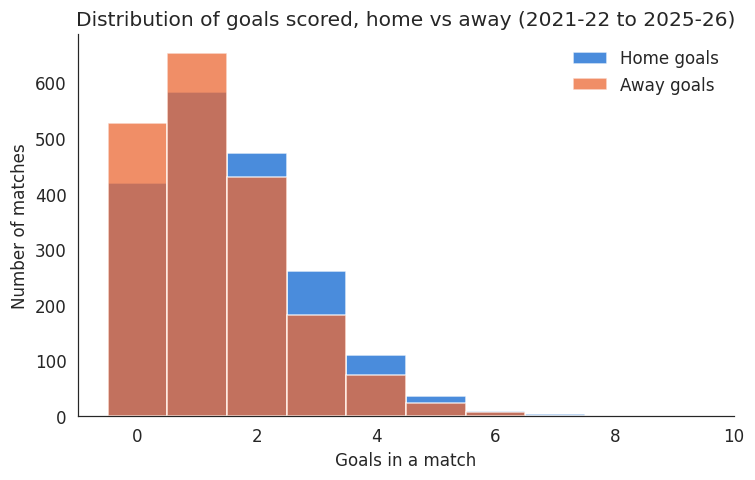

Mean home goals: 1.597
Mean away goals: 1.329


In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bins = np.arange(0, matches[["home_goals", "away_goals"]].values.max() + 2) - 0.5

ax.hist(matches["home_goals"], bins=bins, alpha=0.85, label="Home goals", color=CAT["blue"])
ax.hist(matches["away_goals"], bins=bins, alpha=0.75, label="Away goals", color=CAT["orange"])

ax.set_xlabel("Goals in a match")
ax.set_ylabel("Number of matches")
ax.set_title("Distribution of goals scored, home vs away (2021-22 to 2025-26)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("Mean home goals:", round(matches["home_goals"].mean(), 3))
print("Mean away goals:", round(matches["away_goals"].mean(), 3))

## 3. Home advantage

Home teams famously score more and win more often. Let's quantify it, and check
whether it has held steady across the 5 seasons.

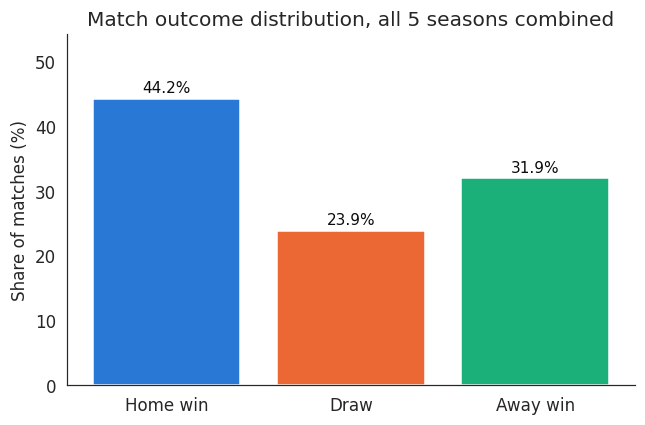

In [5]:
outcome_counts = matches["result"].value_counts(normalize=True).reindex(["H", "D", "A"])
outcome_labels = {"H": "Home win", "D": "Draw", "A": "Away win"}

fig, ax = plt.subplots(figsize=(6, 4))
colors = [CAT["blue"], CAT["orange"], CAT["aqua"]]
bars = ax.bar([outcome_labels[k] for k in outcome_counts.index], outcome_counts.values * 100, color=colors)

for b, v in zip(bars, outcome_counts.values * 100):
    ax.text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.1f}%", ha="center", color=INK, fontsize=10)

ax.set_ylabel("Share of matches (%)")
ax.set_title("Match outcome distribution, all 5 seasons combined")
ax.set_ylim(0, outcome_counts.max() * 100 + 10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

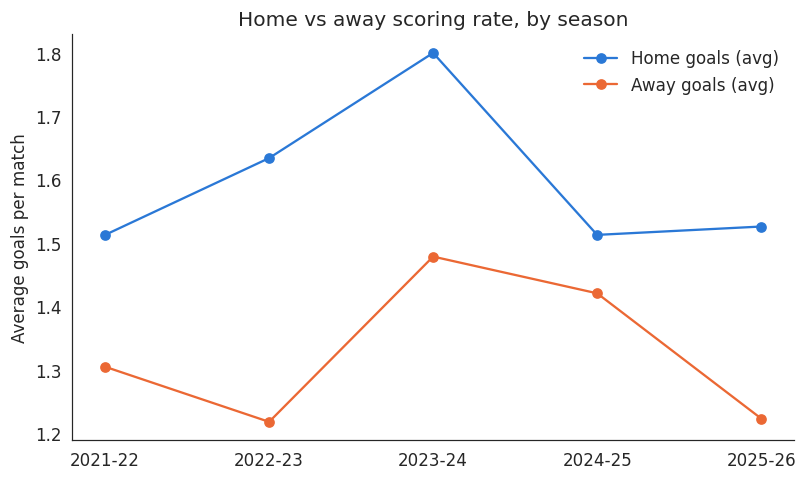

,home_goals,away_goals,home_advantage
season,,,
2021-22,1.513,1.305,0.208
2022-23,1.634,1.218,0.416
2023-24,1.800,1.479,0.321
2024-25,1.513,1.421,0.092
2025-26,1.526,1.224,0.303


In [6]:
season_goals = matches.groupby("season")[["home_goals", "away_goals"]].mean()

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(season_goals.index, season_goals["home_goals"], marker="o", color=CAT["blue"], label="Home goals (avg)")
ax.plot(season_goals.index, season_goals["away_goals"], marker="o", color=CAT["orange"], label="Away goals (avg)")

ax.set_ylabel("Average goals per match")
ax.set_title("Home vs away scoring rate, by season")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

season_goals["home_advantage"] = season_goals["home_goals"] - season_goals["away_goals"]
season_goals.round(3)

## 4. Shots on target as an expected-goals proxy

Actual xG data isn't in the free football-data.co.uk feed, so the plan is to use
shot volume and shot quality (shots on target) as a proxy. Let's check how well
shots on target actually predict goals scored — if the relationship is weak, the
proxy isn't worth much.

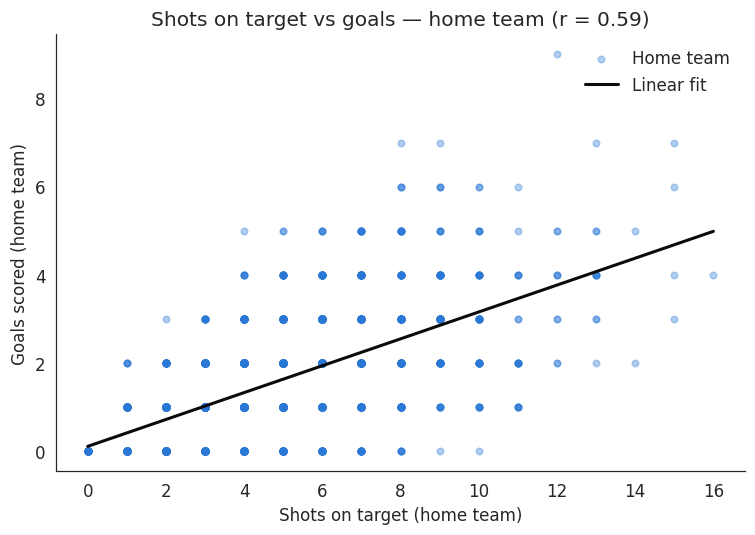

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(matches["home_shots_target"], matches["home_goals"],
           alpha=0.35, s=18, color=CAT["blue"], label="Home team")

coeffs = np.polyfit(matches["home_shots_target"], matches["home_goals"], 1)
xs = np.linspace(matches["home_shots_target"].min(), matches["home_shots_target"].max(), 100)
ax.plot(xs, np.polyval(coeffs, xs), color=INK, linewidth=2, label="Linear fit")

corr = matches["home_shots_target"].corr(matches["home_goals"])
ax.set_xlabel("Shots on target (home team)")
ax.set_ylabel("Goals scored (home team)")
ax.set_title(f"Shots on target vs goals — home team (r = {corr:.2f})")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

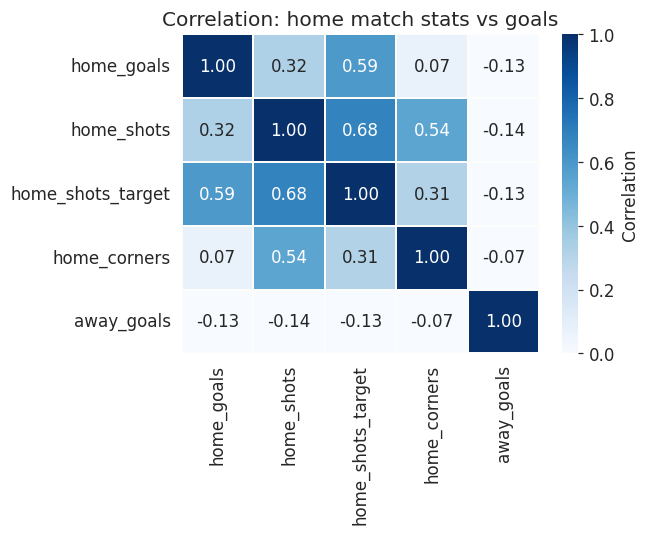

In [8]:
stat_cols = ["home_goals", "home_shots", "home_shots_target", "home_corners", "away_goals"]
corr_matrix = matches[stat_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
    linewidths=1, linecolor="#fcfcfb", cbar_kws={"label": "Correlation"}, ax=ax,
)
ax.set_title("Correlation: home match stats vs goals")
plt.tight_layout()
plt.show()

## 5. Team-level scoring, across seasons played

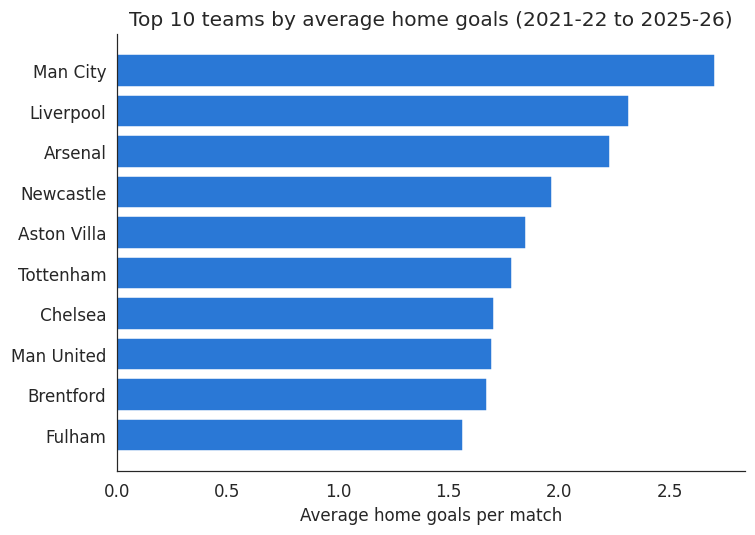

,avg_home_goals,matches_played
home_team,,
Man City,2.705263,95
Liverpool,2.315789,95
Arsenal,2.231579,95
Newcastle,1.968421,95
Aston Villa,1.852632,95
Tottenham,1.789474,95
Chelsea,1.705263,95
Man United,1.694737,95
Brentford,1.673684,95


In [9]:
team_goals = (
    matches.groupby("home_team")["home_goals"].agg(["mean", "count"])
    .rename(columns={"mean": "avg_home_goals", "count": "matches_played"})
    .sort_values("avg_home_goals", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(team_goals.index[::-1], team_goals["avg_home_goals"][::-1], color=CAT["blue"])
ax.set_xlabel("Average home goals per match")
ax.set_title("Top 10 teams by average home goals (2021-22 to 2025-26)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

team_goals

## Key takeaways for feature engineering

- **Home advantage is real and consistent**: home teams score more on average
  and win close to half of all matches across every season in this window.
- **Shots on target correlate meaningfully with goals scored**, which supports
  using shot-based features (shots, shots on target, corners) as an expected-goals
  proxy in the absence of real xG data.
- Goal counts are low and discrete (0-6 in the vast majority of matches), which
  points toward **Poisson-style models** rather than plain linear regression for
  the expected-goals target.
- Team-level scoring varies widely, and squads change between seasons (promotion
  / relegation), so features should be built on **rolling recent form** rather
  than full-history team averages.

Next step: feature engineering (`src/features.py`) — rolling form, attack/defence
strength ratings, and the shot-based xG proxy — feeding into the expected-goals
models.